In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("messy_ecommerce_15000_student_practice.csv")

In [ ]:
numerical_columns = df.select_dtypes(include="number").columns
print("Numerical Columns:", numerical_columns.tolist())

print(df[numerical_columns].describe())

summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std Dev": df[numerical_columns].std(),
    "Min": df[numerical_columns].min(),
    "25th Percentile": df[numerical_columns].quantile(0.25),
    "50th Percentile": df[numerical_columns].quantile(0.50),
    "75th Percentile": df[numerical_columns].quantile(0.75),
    "Max": df[numerical_columns].max()
})

summary["Range"] = summary["Max"] - summary["Min"]

print(summary)

print(summary.sort_values(by="Range", ascending=False))

""" Short Observations
Age has a mean and median close to 32, showing a fairly balanced distribution.
Quantity has an average of around 2 items per order.
Unit_Price has a large difference between mean and median, indicating possible high-value outliers.
Total_Amount has the largest minimum–maximum range, showing high variation in order values.
Rating is fairly consistent, with an average close to 3.9 out of 5.
"""

Numerical Columns: ['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']
                Age      Quantity     Unit_Price      Discount        Rating  \
count  14804.000000  15075.000000   15075.000000  14954.000000  14694.000000   
mean      32.315185      1.899768    7409.180453     12.016852      3.869171   
std        9.022506      1.076839   13950.011077      7.696562      0.741548   
min        5.000000      1.000000     425.610000      0.000000      1.000000   
25%       26.000000      1.000000    1248.315000      5.000000      3.400000   
50%       32.000000      2.000000    2480.280000     10.000000      3.900000   
75%       38.000000      2.000000    3811.455000     15.000000      4.400000   
max       99.000000      5.000000  309655.380000     30.000000      5.000000   

       Delivery_Days  Total_Amount  
count   14895.000000  1.507500e+04  
mean        4.489359  1.255336e+04  
std         1.961563  2.955080e+04  
min         1.000000  2

In [ ]:

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

print("\nCategorical Summary:")
print(df[categorical_columns].describe())

summary = pd.DataFrame({
    "Unique Values": df[categorical_columns].nunique(),
    "Most Frequent": df[categorical_columns].mode().iloc[0],
    "Frequency": df[categorical_columns].apply(
        lambda x: x.value_counts().iloc[0]
    )
})

print("\nCategorical Analysis:")
print(summary)

columns = ["Gender", "City", "Product_Category",
           "Payment_Method", "Returned"]

for col in columns:
    print(f"\nMost common {col}: {df[col].mode()[0]}")

Categorical Columns:
['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category', 'Product', 'Payment_Method', 'Order_Date', 'Returned']

Categorical Summary:
         Order_ID Customer_ID  Gender     City Product_Category     Product  \
count       15075       15075   14896    14925            15075       15075   
unique      15000        6795       5       12                6          30   
top     ORD100543    CUST1345  Female  Kolkata      Electronics  Smartwatch   
freq            2           8    7292     1274             3815         798   

       Payment_Method  Order_Date Returned  
count           14849       15075    15075  
unique              8         730        3  
top       Credit Card  2026-05-29       No  
freq             2510          41    13229  

Categorical Analysis:
                  Unique Values Most Frequent  Frequency
Order_ID                  15000     ORD100150          2
Customer_ID                6795      CUST1345          8
Gender               

In [ ]:
unique_columns = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Returned"
]

for col in unique_columns:
    print(f"\n{col}")
    print("Unique Values:", df[col].unique())
    print("Number of Unique Values:", df[col].nunique())


check_columns = ["Gender", "Payment_Method", "Returned"]

print("\n--- BEFORE STANDARDIZATION ---")

for col in check_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

for col in check_columns:
    df[col] = df[col].str.strip().str.lower()

df["Gender"] = df["Gender"].replace({
    "male": "Male",
    "female": "Female"
})

df["Payment_Method"] = df["Payment_Method"].replace({
    "upi": "UPI",
    "credit card": "Credit Card",
    "debit card": "Debit Card",
    "cash on delivery": "Cash on Delivery"
})
df["Returned"] = df["Returned"].replace({
    "yes": "Yes",
    "no": "No"
})

print("\n--- AFTER STANDARDIZATION ---")

for col in check_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Gender
Unique Values: <StringArray>
['Male', 'Female', 'Other', nan, 'female', 'male']
Length: 6, dtype: str
Number of Unique Values: 5

City
Unique Values: <StringArray>
[    'Hyderabad',         'Delhi',          'Pune',       'Chennai',
       'Kolkata',     'Ahmedabad',    'Vijayawada',     'Bengaluru',
        'Guntur', 'Visakhapatnam',      'Warangal',        'Mumbai',
             nan]
Length: 13, dtype: str
Number of Unique Values: 12

Product_Category
Unique Values: <StringArray>
['Fashion', 'Sports', 'Electronics', 'Home & Kitchen', 'Beauty', 'Books']
Length: 6, dtype: str
Number of Unique Values: 6

Payment_Method
Unique Values: <StringArray>
[ 'Debit Card',         'UPI',         'COD', 'Net Banking', 'Credit Card',
           nan,      'Wallet',         'upi', 'credit card']
Length: 9, dtype: str
Number of Unique Values: 8

Returned
Unique Values: <StringArray>
['No', 'Yes', 'yes']
Length: 3, dtype: str
Number of Unique Values: 3

--- BEFORE STANDARDIZATION ---

Gender:
G

In [ ]:
print("Missing Values Before:")
print(df.isnull().sum())

numerical_columns = ["Age", "Discount", "Rating", "Delivery_Days"]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = ["Gender", "City", "Payment_Method"]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After:")
print(df.isnull().sum())

Missing Values Before:
Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64

Missing Values After:
Order_ID            0
Customer_ID         0
Age                 0
Gender              0
City                0
Product_Category    0
Product             0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Date          0
Rating              0
Delivery_Days       0
Returned            0
Total_Amount        0
dtype: int64


In [ ]:
missing_count = df.isnull().sum()

print("Missing Values After Treatment:")
print(missing_count)
missing_percentage = (missing_count / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

if missing_count.sum() == 0:
    print("\nDataset is completely free of missing values.")
else:
    print("\nDataset still contains missing values.")

print("\nDataset Dimensions Comparison:")
print("Before Treatment: (15075, 16)")
print("After Treatment:", df.shape)

Missing Values After Treatment:
Order_ID            0
Customer_ID         0
Age                 0
Gender              0
City                0
Product_Category    0
Product             0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Date          0
Rating              0
Delivery_Days       0
Returned            0
Total_Amount        0
dtype: int64

Missing Value Percentage:
Order_ID            0.0
Customer_ID         0.0
Age                 0.0
Gender              0.0
City                0.0
Product_Category    0.0
Product             0.0
Quantity            0.0
Unit_Price          0.0
Discount            0.0
Payment_Method      0.0
Order_Date          0.0
Rating              0.0
Delivery_Days       0.0
Returned            0.0
Total_Amount        0.0
dtype: float64

Dataset is completely free of missing values.

Dataset Dimensions Comparison:
Before Treatment: (15075, 16)
After Treatment: (15075, 16)


In [ ]:
total_duplicates = df.duplicated().sum()

print("Total Exact Duplicate Rows:", total_duplicates)

duplicate_records = df[df.duplicated(keep=False)]

print("\nDuplicate Records:")
print(duplicate_records)

duplicate_order_ids = df[df.duplicated(subset="Order_ID", keep=False)]

print("\nDuplicate Order_ID Records:")
print(duplicate_order_ids.sort_values(by="Order_ID"))

print("\nNumber of Duplicate Order_ID Values:",
      df["Order_ID"].duplicated().sum())


print("\nDuplicate Analysis:")

if total_duplicates > 0:
    print("Exact duplicate rows found:", total_duplicates)
else:
    print("No exact duplicate rows found.")

if df["Order_ID"].duplicated().sum() > 0:
    print("Partial duplicates found based on Order_ID.")
else:
    print("No duplicate Order_ID values found.")

Total Exact Duplicate Rows: 75

Duplicate Records:
        Order_ID Customer_ID   Age  Gender           City Product_Category  \
33     ORD100543    CUST6787  28.0    Male        Chennai           Sports   
34     ORD100150    CUST8539  26.0  Female          Delhi      Electronics   
36     ORD106707    CUST8989  21.0    Male      Hyderabad      Electronics   
50     ORD103976    CUST3601  67.0    Male      Ahmedabad      Electronics   
106    ORD100252    CUST2938  37.0    Male          Delhi           Sports   
...          ...         ...   ...     ...            ...              ...   
14317  ORD105971    CUST5059  44.0    Male      Hyderabad          Fashion   
14605  ORD111737    CUST3702  35.0  Female         Guntur           Sports   
14662  ORD100150    CUST8539  26.0  Female          Delhi      Electronics   
14744  ORD114868    CUST6100  31.0    Male  Visakhapatnam      Electronics   
14859  ORD103018    CUST5249  29.0    Male         Guntur      Electronics   

           P

In [ ]:
records_before = len(df)
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
records_after = len(df)
remaining_duplicates = df.duplicated().sum()
print("Records Before Removing Duplicates:", records_before)
print("Number of Duplicate Records:", duplicate_count)
print("Records After Removing Duplicates:", records_after)
print("Remaining Duplicate Records:", remaining_duplicates)
print("\nDataset Dimensions After Removing Duplicates:")
print(df.shape)
if remaining_duplicates == 0:
    print("\nAll exact duplicate records have been removed successfully.")
else:
    print("\nSome duplicate records still remain.")

Records Before Removing Duplicates: 15075
Number of Duplicate Records: 75
Records After Removing Duplicates: 15000
Remaining Duplicate Records: 0

Dataset Dimensions After Removing Duplicates:
(15000, 16)

All exact duplicate records have been removed successfully.


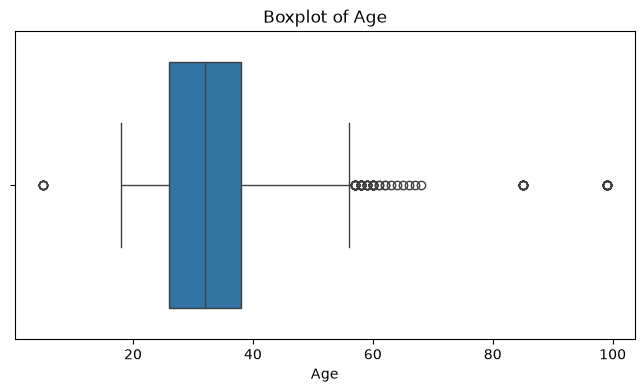

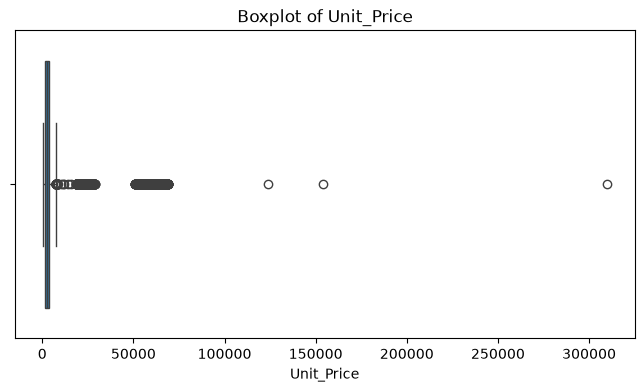

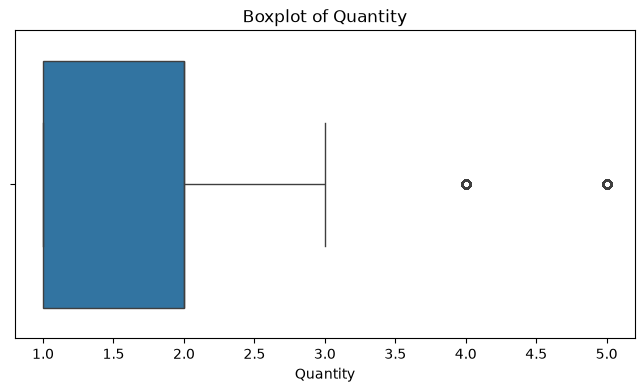

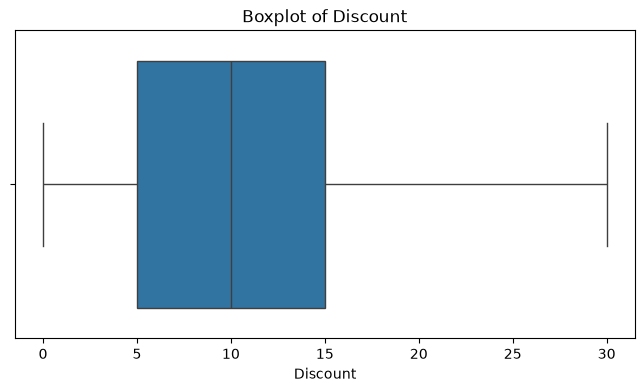

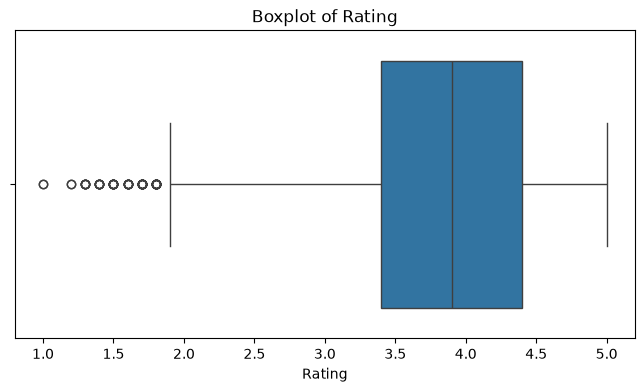

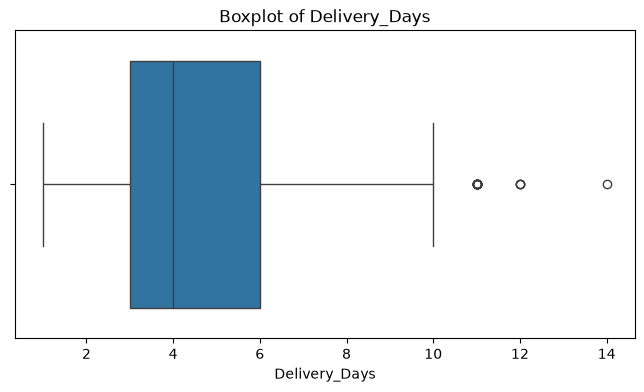

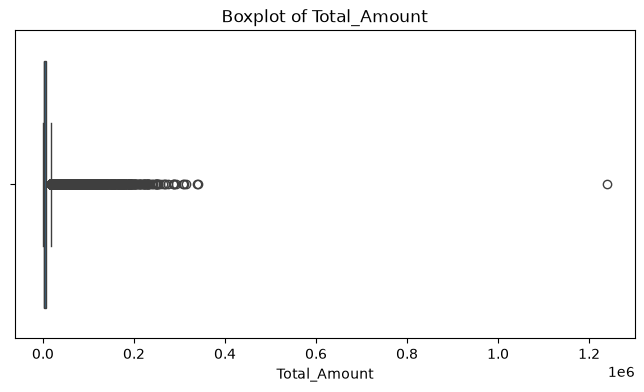

In [ ]:
columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

for col in columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

    """" 
1. Possible outliers: Check the points appearing outside the whiskers in each boxplot.
       Based on the earlier statistical summary, Unit_Price and Total_Amount are the strongest
       candidates for significant outliers because they have very large ranges and high standard deviations.

2. Largest number of extreme values: Unit_Price or Total_Amount should be investigated closely. 
    Confirm which has more by looking at the generated boxplots rather than assuming from summary statistics alone.

3. Are all outliers errors? No. An outlier may represent a genuine expensive product, a large order, or an unusual but valid customer value.

4. Outliers requiring further investigation: Focus especially on extremely high values in Unit_Price and Total_Amount. Also investigate unusual values in Age,
      particularly values that appear inconsistent with realistic customer age"""

In [ ]:
"""" 
1. Possible outliers: Unit_Price and Total_Amount show possible significant outliers. Age may also contain some unusual values.

2. Largest number of extreme values: Based on the boxplots, compare Unit_Price and Total_Amount; the one with more points outside the whiskers has the largest number of extreme values.

3. Are all outliers errors? No. Some outliers may be valid, such as expensive products or large customer orders.

4. Outliers requiring investigation: Extremely high values in Unit_Price and Total_Amount, and unrealistic values in Age, should be investigated further.

"""

In [ ]:
columns = ["Age", "Unit_Price", "Total_Amount"]

for col in columns:


    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

   
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outlier records
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    # Display results
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")

    print("\nOutlier Records:")
    print(outliers[[col]])


Column: Age
Q1: 26.0
Q3: 38.0
IQR: 12.0
Lower Bound: 8.0
Upper Bound: 56.0
Number of Outliers: 90

Outlier Records:
        Age
50     67.0
98     99.0
703    57.0
748    60.0
885    60.0
...     ...
14489  60.0
14548  60.0
14562  59.0
14904  59.0
14946  99.0

[90 rows x 1 columns]

Column: Unit_Price
Q1: 1249.04
Q3: 3819.2974999999997
IQR: 2570.2574999999997
Lower Bound: -2606.3462499999996
Upper Bound: 7674.683749999999
Number of Outliers: 2401

Outlier Records:
       Unit_Price
3         7739.89
4        61138.76
9        21716.46
22       19950.50
35       65832.03
...           ...
15035     7861.75
15041     7837.06
15057    64219.73
15063    22569.06
15067    27537.22

[2401 rows x 1 columns]

Column: Total_Amount
Q1: 1741.9099999999999
Q3: 7741.01
IQR: 5999.1
Lower Bound: -7256.740000000002
Upper Bound: 16739.660000000003
Number of Outliers: 2472

Outlier Records:
       Total_Amount
4          58081.82
9          39089.63
22         37905.95
35         65832.03
38        159

In [14]:
# =====================================
# OUTLIER DECISION
# =====================================

# Store original number of records
records_before = len(df)

# Function to identify IQR outliers
def get_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[column] < lower_bound) |
                (data[column] > upper_bound)]


# Check outliers in selected columns
columns = ["Age", "Unit_Price", "Total_Amount"]

for col in columns:
    outliers = get_outliers(df, col)

    print(f"\n{'=' * 40}")
    print(f"{col} Outliers")
    print("Number of outliers:", len(outliers))
    print(outliers[[col]])


# Decision: Remove only clearly invalid Age values
# Assuming customers should be at least 18 years old
invalid_age = df["Age"] < 18

print("\nClearly Invalid Age Records:", invalid_age.sum())

# Remove only justified invalid records
df = df[~invalid_age]

# Keep Unit_Price and Total_Amount outliers
# They may represent legitimate expensive products or large orders

# Verify result
records_after = len(df)

print("\nRecords Before Removal:", records_before)
print("Records Removed:", records_before - records_after)
print("Records After Removal:", records_after)

"""" 
1. Age outliers: Values that are clearly unrealistic for customers can be considered possible data-entry errors and removed only when justified.
2. Unit_Price outliers: High prices are retained because they may represent genuinely expensive products.
3. Total_Amount outliers: High order amounts are retained because they may represent legitimate large purchases.
4. Suspicious values: Values without sufficient evidence of being errors should be investigated rather than automatically removed.
"""


Age Outliers
Number of outliers: 90
        Age
50     67.0
98     99.0
703    57.0
748    60.0
885    60.0
...     ...
14489  60.0
14548  60.0
14562  59.0
14904  59.0
14946  99.0

[90 rows x 1 columns]

Unit_Price Outliers
Number of outliers: 2401
       Unit_Price
3         7739.89
4        61138.76
9        21716.46
22       19950.50
35       65832.03
...           ...
15035     7861.75
15041     7837.06
15057    64219.73
15063    22569.06
15067    27537.22

[2401 rows x 1 columns]

Total_Amount Outliers
Number of outliers: 2472
       Total_Amount
4          58081.82
9          39089.63
22         37905.95
35         65832.03
38        159469.68
...             ...
15034     160756.06
15035      22405.99
15057     115595.51
15063      54165.73
15067     130801.79

[2472 rows x 1 columns]

Clearly Invalid Age Records: 6

Records Before Removal: 15000
Records Removed: 6
Records After Removal: 14994


In [15]:
# =====================================
# DATA CONSISTENCY VALIDATION
# =====================================

# 1. Calculate expected total amount
df["Expected_Total"] = (
    df["Unit_Price"] *
    df["Quantity"] *
    (1 - df["Discount"] / 100)
)

# 2 & 3. Calculate the difference
df["Amount_Difference"] = abs(
    df["Expected_Total"] - df["Total_Amount"]
)

# 4. Identify records with large differences
# Using a small tolerance for rounding differences
large_difference = df[df["Amount_Difference"] > 1]

print("Total Records:", len(df))
print("Records with Large Differences:", len(large_difference))

print("\nRecords with Large Differences:")
print(
    large_difference[
        ["Order_ID", "Unit_Price", "Quantity", "Discount",
         "Expected_Total", "Total_Amount", "Amount_Difference"]
    ]
)

# 5. Check the largest differences
print("\nTop 10 Largest Differences:")
print(
    large_difference[
        ["Order_ID", "Expected_Total", "Total_Amount",
         "Amount_Difference"]
    ]
    .sort_values(by="Amount_Difference", ascending=False)
    .head(10)
)

Total Records: 14994
Records with Large Differences: 87

Records with Large Differences:
        Order_ID  Unit_Price  Quantity  Discount  Expected_Total  \
14     ORD102407     1394.37         3      10.0        3764.799   
119    ORD114201     3174.41         2      10.0        5713.938   
204    ORD102563      605.90         2      10.0        1090.620   
435    ORD107415     2355.10         1      10.0        2119.590   
562    ORD101689     1693.03         1      10.0        1523.727   
...          ...         ...       ...       ...             ...   
14763  ORD100660     1677.97         1      10.0        1510.173   
14941  ORD109688      945.06         5      10.0        4252.770   
14977  ORD110174    22117.21         4      10.0       79621.956   
15006  ORD109556    51845.68         3      10.0      139983.336   
15009  ORD107514      616.17         4      10.0        2218.212   

       Total_Amount  Amount_Difference  
14          3555.64            209.159  
119         

In [16]:
# =====================================
# FINAL DATA QUALITY CHECK
# =====================================

import pandas as pd

# 1. Dataset dimensions
print("1. DATASET DIMENSIONS")
print(df.shape)


# 2. Data types
print("\n2. DATA TYPES")
print(df.dtypes)


# 3. Missing values
print("\n3. MISSING VALUES")
print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())


# 4. Duplicate records
print("\n4. DUPLICATE RECORDS")
print("Exact Duplicate Rows:", df.duplicated().sum())


# 5. Unique values
print("\n5. UNIQUE VALUES")
columns = ["Gender", "City", "Product_Category",
           "Payment_Method", "Returned"]

for col in columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())


# 6. Categorical consistency
print("\n6. CATEGORICAL CONSISTENCY")

for col in ["Gender", "Payment_Method", "Returned"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


# 7. Outliers using IQR
print("\n7. OUTLIER CHECK")

numerical_columns = [
    "Age", "Unit_Price", "Quantity",
    "Discount", "Rating",
    "Delivery_Days", "Total_Amount"
]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    print(f"{col}: {outlier_count} possible outliers")


# 8. Statistical summary
print("\n8. STATISTICAL SUMMARY")
print(df.describe())


# 9. Date format
print("\n9. DATE FORMAT CHECK")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print("Order_Date Data Type:", df["Order_Date"].dtype)
print("Invalid Dates:", df["Order_Date"].isnull().sum())


# 10. Data consistency validation
print("\n10. DATA CONSISTENCY CHECK")

df["Expected_Total"] = (
    df["Unit_Price"] *
    df["Quantity"] *
    (1 - df["Discount"] / 100)
)

df["Amount_Difference"] = abs(
    df["Expected_Total"] - df["Total_Amount"]
)

large_differences = df[df["Amount_Difference"] > 1]

print("Records with Large Amount Differences:",
      len(large_differences))

print("\nTop 5 Largest Differences:")
print(
    large_differences[
        ["Order_ID", "Expected_Total",
         "Total_Amount", "Amount_Difference"]
    ]
    .sort_values(
        by="Amount_Difference",
        ascending=False
    )
    .head()
)


# FINAL RESULT
print("\n=====================================")
print("FINAL DATA QUALITY RESULT")
print("=====================================")

if (
    df.isnull().sum().sum() == 0
    and df.duplicated().sum() == 0
):
    print("The dataset has no missing values and no exact duplicates.")
    print("The dataset is ready for Exploratory Data Analysis (EDA).")
    print("However, possible outliers and records with large")
    print("amount differences should be considered during analysis.")
else:
    print("The dataset still has data quality issues.")

1. DATASET DIMENSIONS
(14994, 18)

2. DATA TYPES
Order_ID                 str
Customer_ID              str
Age                  float64
Gender                   str
City                     str
Product_Category         str
Product                  str
Quantity               int64
Unit_Price           float64
Discount             float64
Payment_Method           str
Order_Date               str
Rating               float64
Delivery_Days        float64
Returned                 str
Total_Amount         float64
Expected_Total       float64
Amount_Difference    float64
dtype: object

3. MISSING VALUES
Order_ID             0
Customer_ID          0
Age                  0
Gender               0
City                 0
Product_Category     0
Product              0
Quantity             0
Unit_Price           0
Discount             0
Payment_Method       0
Order_Date           0
Rating               0
Delivery_Days        0
Returned             0
Total_Amount         0
Expected_Total       0
Amoun

In [ ]:
""" Yes, the dataset is ready for Exploratory Data Analysis (EDA) because missing values have been handled, exact duplicate records have been removed, 
    categorical values have been standardized, data types have been checked, and the date column has been validated. However, possible outliers and records 
    with large differences between Expected_Total and Total_Amount should be retained for further investigation rather than automatically removed, as they may represent
    legitimate extreme values or business-specific calculations.
"""

In [17]:
# =====================================
# SAVE CLEANED DATASET
# =====================================

# Save cleaned dataset as a new CSV file
df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

print("Cleaned dataset saved successfully as:")
print("cleaned_ecommerce_dataset.csv")

Cleaned dataset saved successfully as:
cleaned_ecommerce_dataset.csv


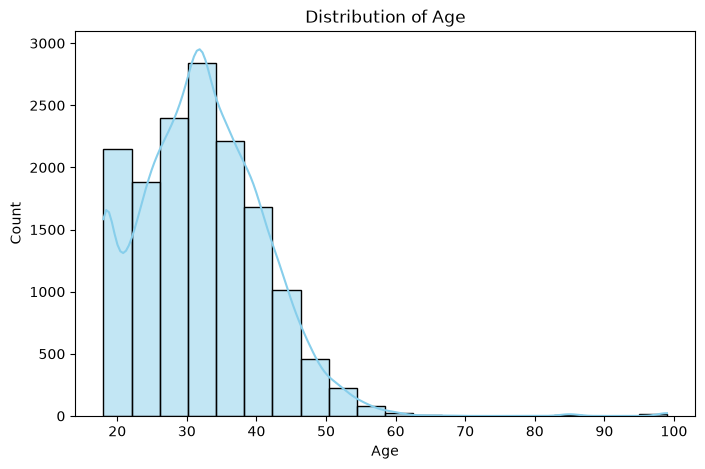

Observation: Most customer ages are concentrated around the central age range.


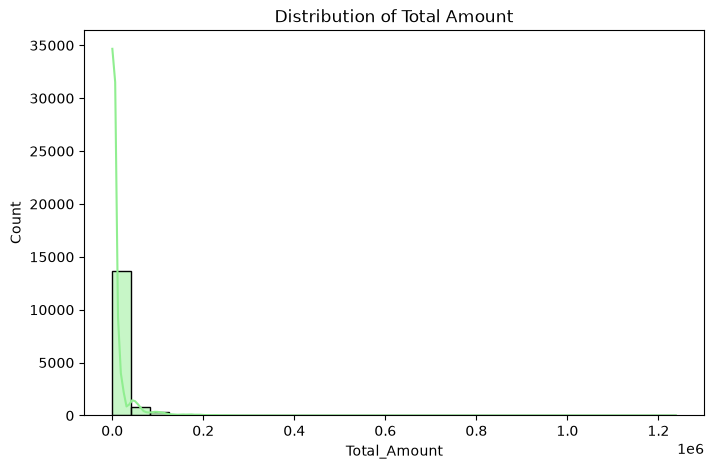

Observation: Most orders have lower amounts, with a few very high-value orders.


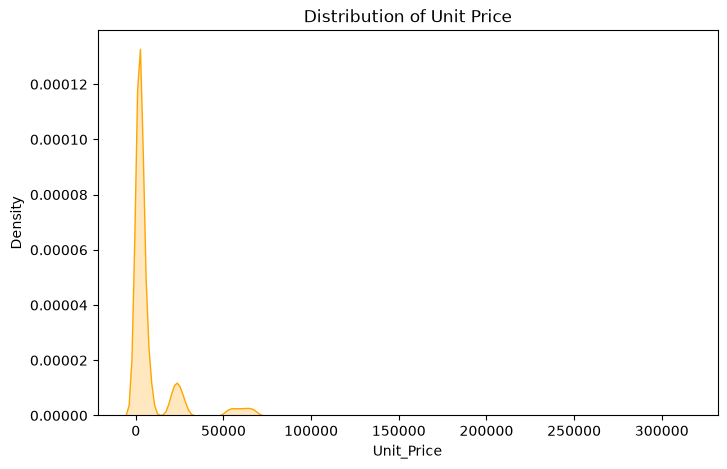

Observation: Most products have lower prices, while a few products have very high prices.


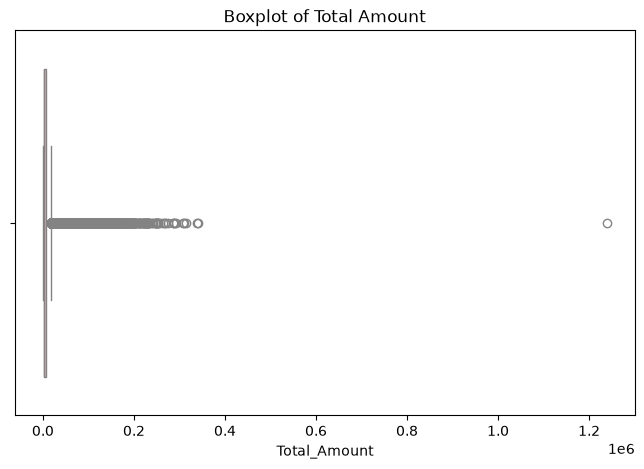

Observation: Total_Amount contains possible high-value outliers.


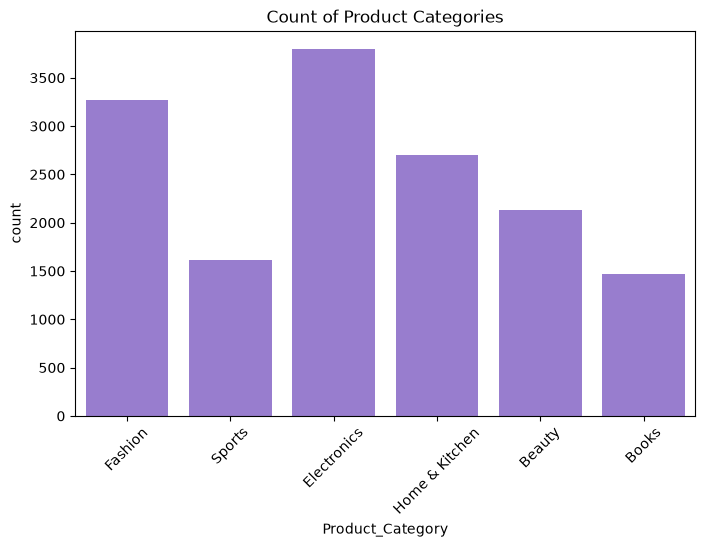

Observation: Some product categories have more orders than others.


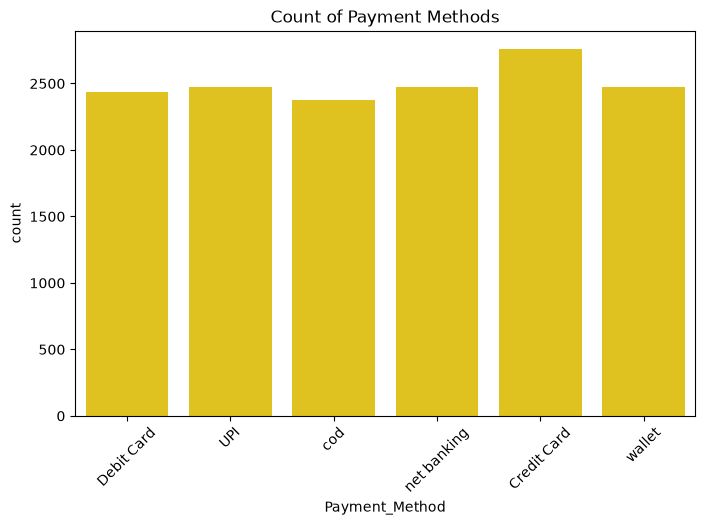

Observation: Customers show different preferences for payment methods.


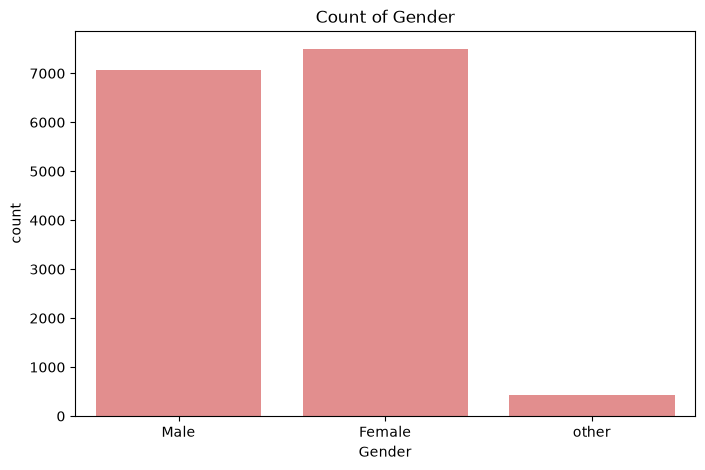

Observation: The chart shows the distribution of customers across gender categories.


In [19]:
# =====================================
# SEABORN UNIVARIATE ANALYSIS
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Histogram of Age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=20, kde=True, color="skyblue")
plt.title("Distribution of Age")
plt.show()

print("Observation: Most customer ages are concentrated around the central age range.")


# 2. Histogram of Total_Amount
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Total_Amount", bins=30, kde=True, color="lightgreen")
plt.title("Distribution of Total Amount")
plt.show()

print("Observation: Most orders have lower amounts, with a few very high-value orders.")


# 3. KDE Plot of Unit_Price
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Unit_Price", fill=True, color="orange")
plt.title("Distribution of Unit Price")
plt.show()

print("Observation: Most products have lower prices, while a few products have very high prices.")


# 4. Boxplot of Total_Amount
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Total_Amount", color="lightpink")
plt.title("Boxplot of Total Amount")
plt.show()

print("Observation: Total_Amount contains possible high-value outliers.")


# 5. Countplot of Product_Category
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Product_Category", color="mediumpurple")
plt.title("Count of Product Categories")
plt.xticks(rotation=45)
plt.show()

print("Observation: Some product categories have more orders than others.")


# 6. Countplot of Payment_Method
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Payment_Method", color="gold")
plt.title("Count of Payment Methods")
plt.xticks(rotation=45)
plt.show()

print("Observation: Customers show different preferences for payment methods.")


# 7. Countplot of Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender", color="lightcoral")
plt.title("Count of Gender")
plt.show()

print("Observation: The chart shows the distribution of customers across gender categories.")

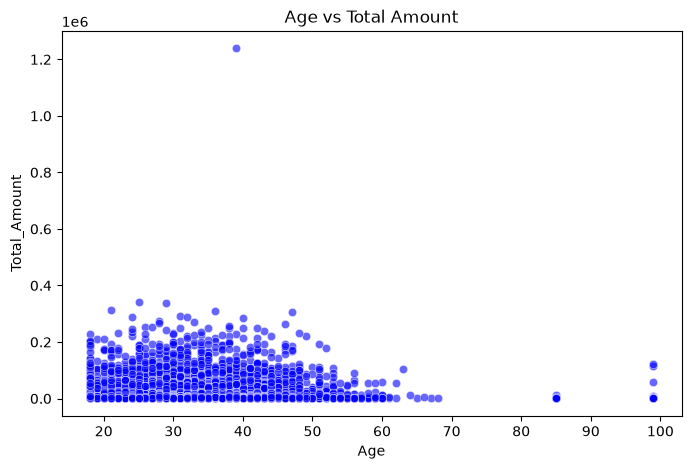

Interpretation: This plot shows whether customer age has any relationship with the total order amount.


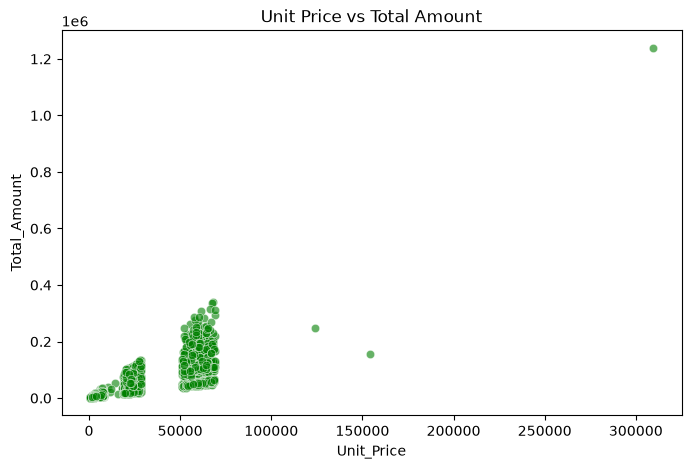

Interpretation: Higher unit prices generally contribute to higher total amounts, although quantity and discount also affect the total.


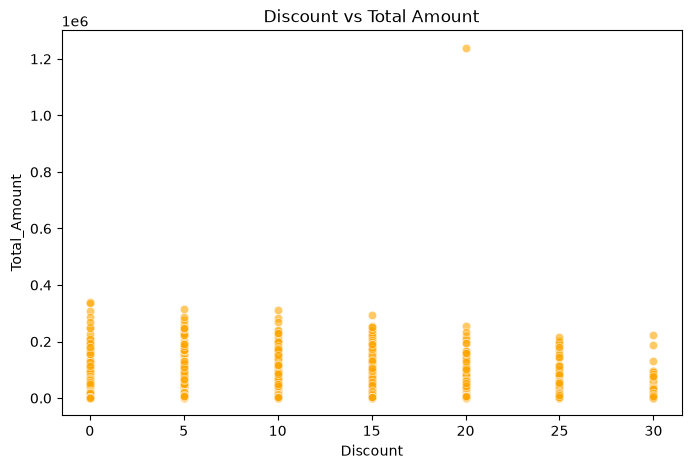

Interpretation: The plot helps identify whether higher discounts are associated with changes in total order amounts.


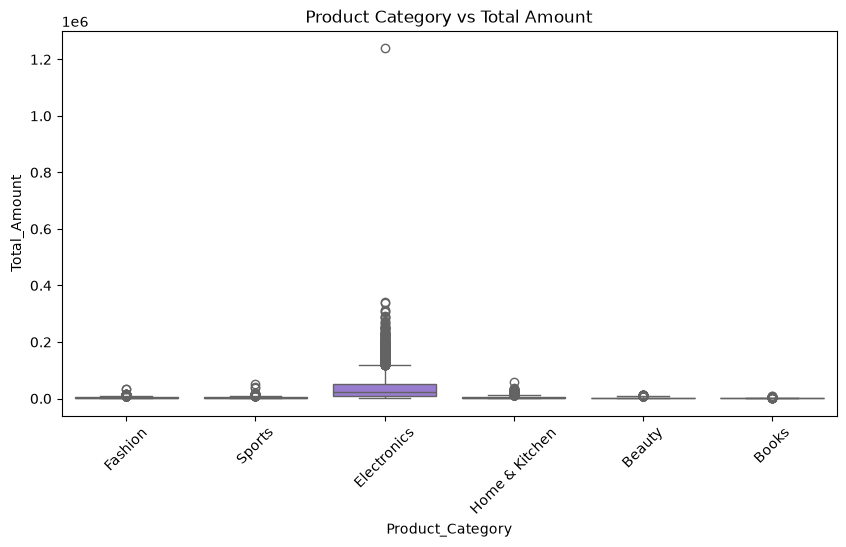

Interpretation: Different product categories show different distributions of order amounts and possible high-value outliers.


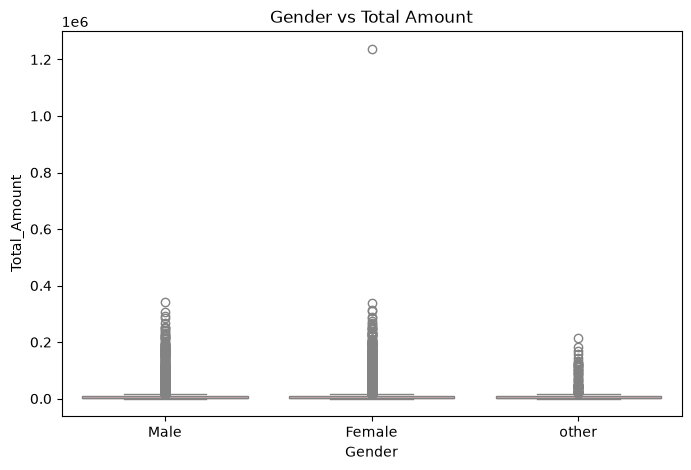

Interpretation: This plot compares the distribution of total order amounts across different gender categories.


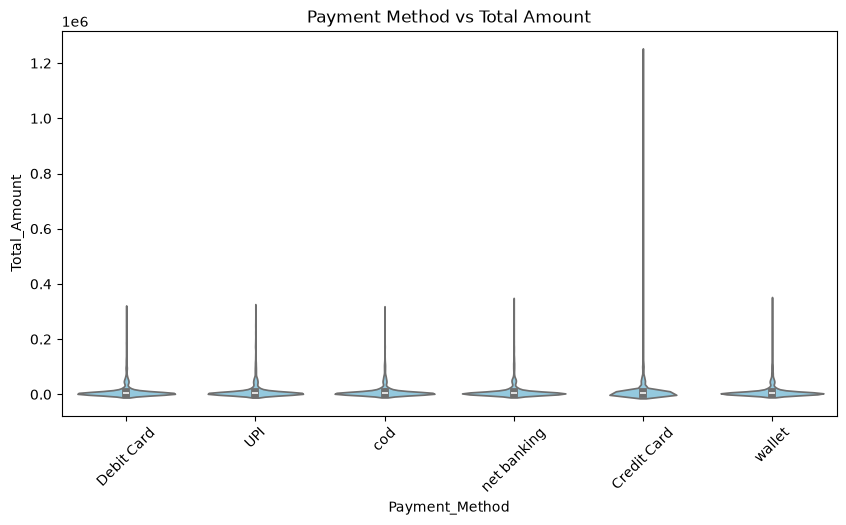

Interpretation: Different payment methods may show different distributions and variations in total order amounts.


In [20]:
# =====================================
# SEABORN BIVARIATE ANALYSIS
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Age vs Total_Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Total_Amount", color="blue", alpha=0.6)
plt.title("Age vs Total Amount")
plt.show()

print("Interpretation: This plot shows whether customer age has any relationship with the total order amount.")


# 2. Unit_Price vs Total_Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Unit_Price", y="Total_Amount", color="green", alpha=0.6)
plt.title("Unit Price vs Total Amount")
plt.show()

print("Interpretation: Higher unit prices generally contribute to higher total amounts, although quantity and discount also affect the total.")


# 3. Discount vs Total_Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Total_Amount", color="orange", alpha=0.6)
plt.title("Discount vs Total Amount")
plt.show()

print("Interpretation: The plot helps identify whether higher discounts are associated with changes in total order amounts.")


# 4. Product_Category vs Total_Amount
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Product_Category", y="Total_Amount", color="mediumpurple")
plt.title("Product Category vs Total Amount")
plt.xticks(rotation=45)
plt.show()

print("Interpretation: Different product categories show different distributions of order amounts and possible high-value outliers.")


# 5. Gender vs Total_Amount
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Gender", y="Total_Amount", color="lightpink")
plt.title("Gender vs Total Amount")
plt.show()

print("Interpretation: This plot compares the distribution of total order amounts across different gender categories.")


# 6. Payment_Method vs Total_Amount
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="Payment_Method", y="Total_Amount", color="skyblue")
plt.title("Payment Method vs Total Amount")
plt.xticks(rotation=45)
plt.show()

print("Interpretation: Different payment methods may show different distributions and variations in total order amounts.")

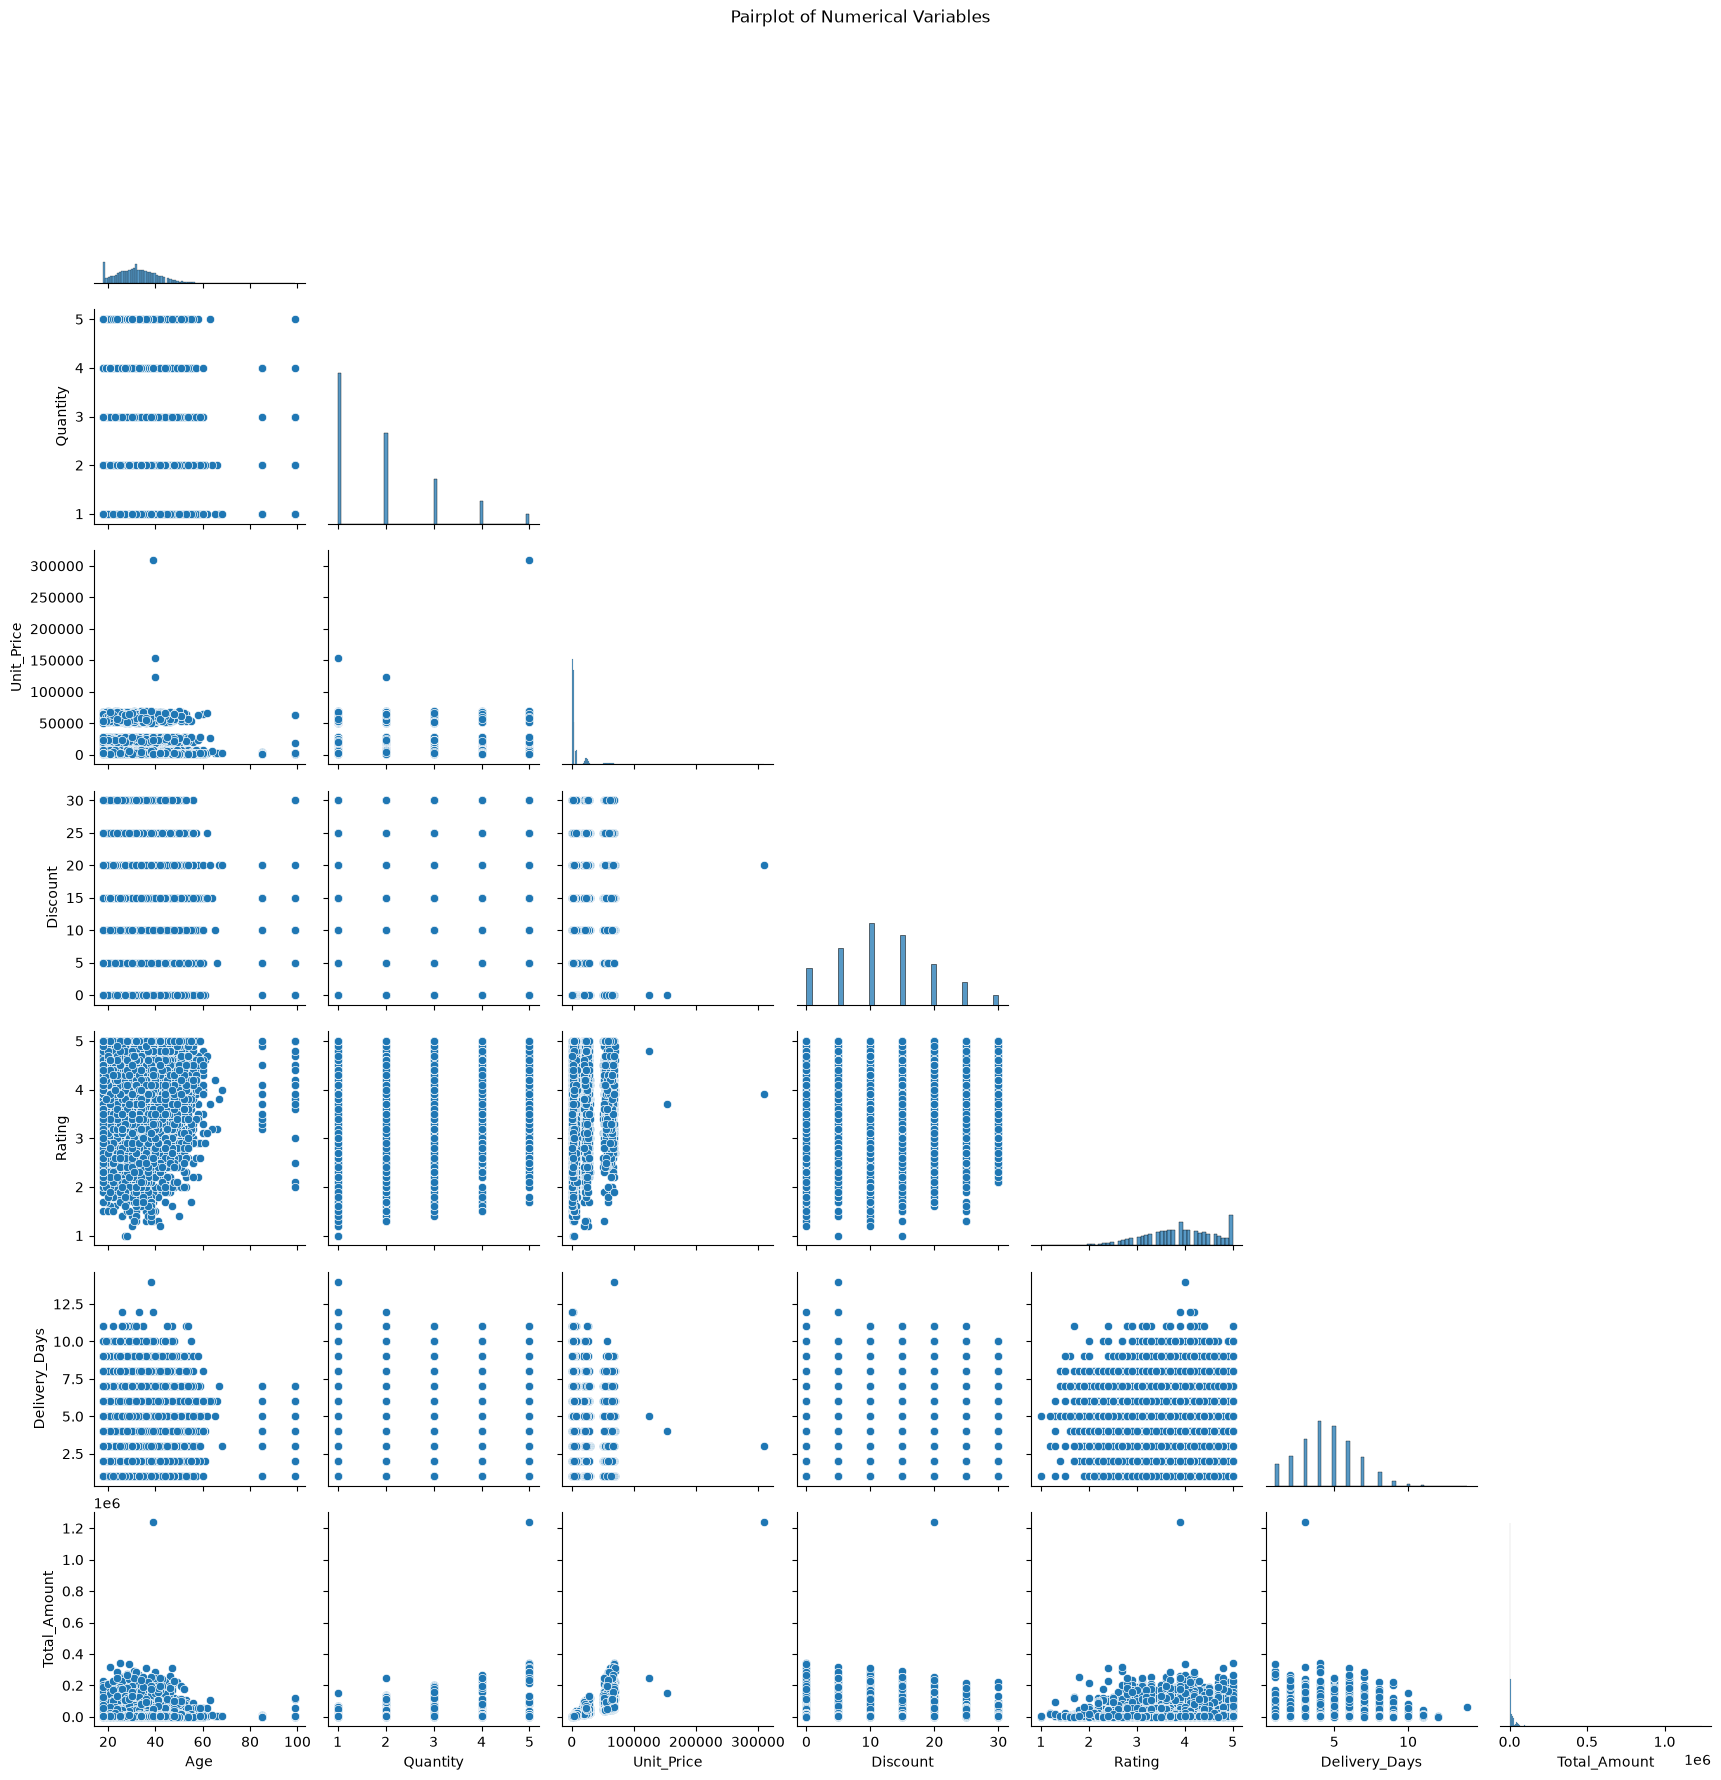

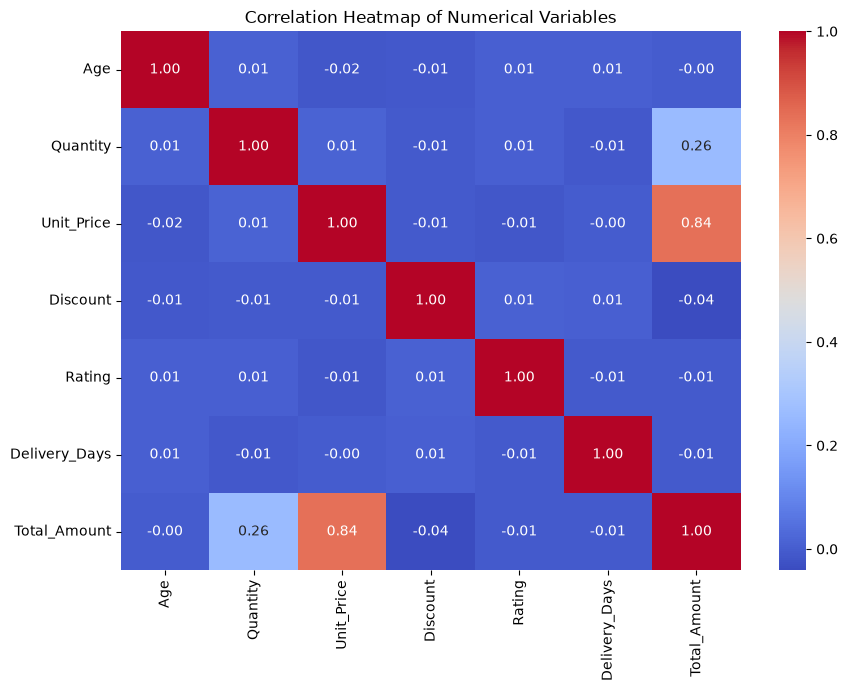

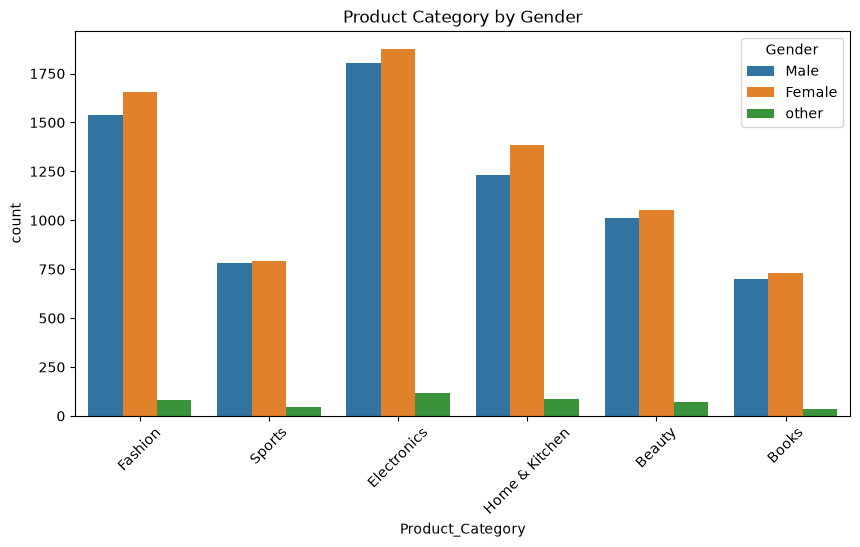

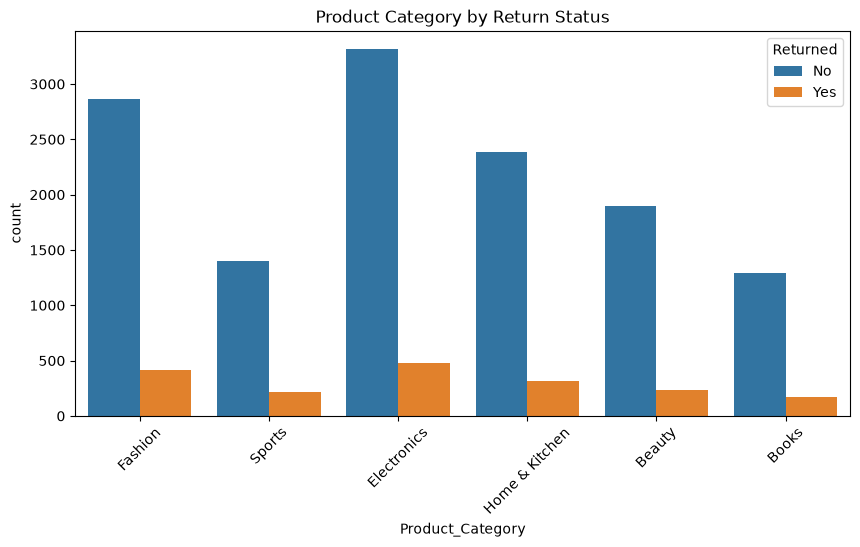

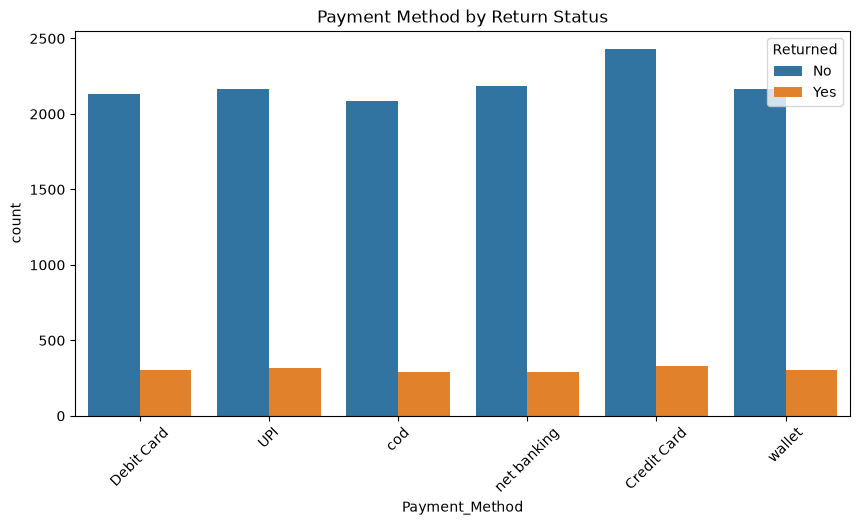

In [21]:
# =====================================
# MULTIVARIATE ANALYSIS USING SEABORN
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns


# 1. PAIRPLOT
selected_columns = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

sns.pairplot(
    df[selected_columns],
    corner=True
)

plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()


# 2. CORRELATION HEATMAP
plt.figure(figsize=(10, 7))

correlation = df[selected_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


# 3. PRODUCT CATEGORY + GENDER
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Gender"
)

plt.title("Product Category by Gender")
plt.xticks(rotation=45)
plt.show()


# 4. PRODUCT CATEGORY + RETURNED
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Returned"
)

plt.title("Product Category by Return Status")
plt.xticks(rotation=45)
plt.show()


# 5. PAYMENT METHOD + RETURNED
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Returned"
)

plt.title("Payment Method by Return Status")
plt.xticks(rotation=45)
plt.show()

CORRELATION MATRIX:
                    Age  Quantity  Unit_Price  Discount    Rating  \
Age            1.000000  0.010995   -0.016739 -0.009592  0.005071   
Quantity       0.010995  1.000000    0.012079 -0.005571  0.007067   
Unit_Price    -0.016739  0.012079    1.000000 -0.005608 -0.014772   
Discount      -0.009592 -0.005571   -0.005608  1.000000  0.007731   
Rating         0.005071  0.007067   -0.014772  0.007731  1.000000   
Delivery_Days  0.005965 -0.009902   -0.000633  0.005011 -0.008010   
Total_Amount  -0.004504  0.255926    0.835049 -0.041196 -0.007997   

               Delivery_Days  Total_Amount  
Age                 0.005965     -0.004504  
Quantity           -0.009902      0.255926  
Unit_Price         -0.000633      0.835049  
Discount            0.005011     -0.041196  
Rating             -0.008010     -0.007997  
Delivery_Days       1.000000     -0.007320  
Total_Amount       -0.007320      1.000000  


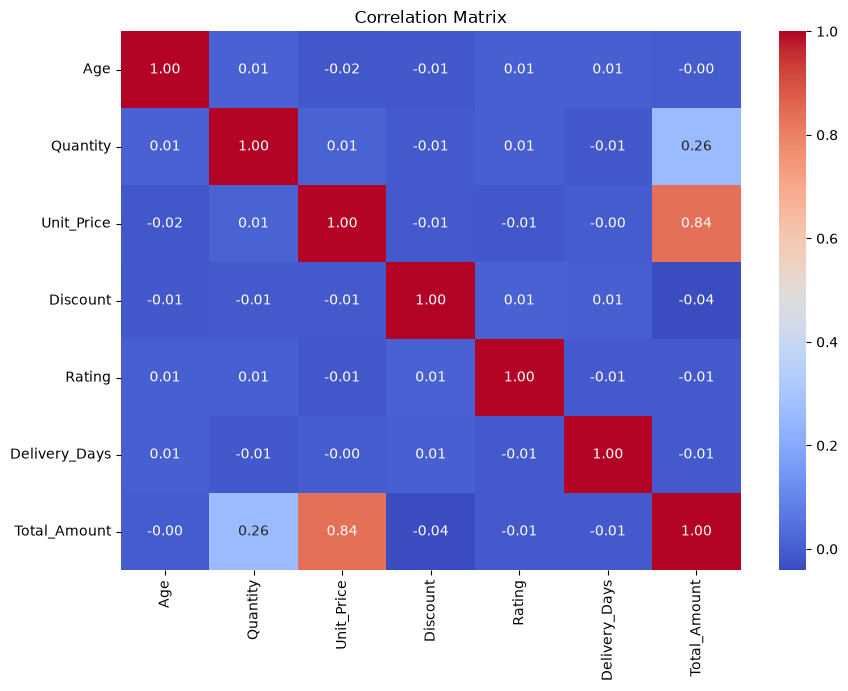


Strongest Positive Correlation:
('Unit_Price', 'Total_Amount') = 0.8350494913822606

Strongest Negative Correlation:
('Discount', 'Total_Amount') = -0.04119591504337983

Correlation with Total_Amount:
Unit_Price       0.835049
Quantity         0.255926
Age             -0.004504
Delivery_Days   -0.007320
Rating          -0.007997
Discount        -0.041196
Name: Total_Amount, dtype: float64

Variables with Weak Correlation with Total_Amount:
Age             -0.004504
Quantity         0.255926
Discount        -0.041196
Rating          -0.007997
Delivery_Days   -0.007320
Name: Total_Amount, dtype: float64

Features Ranked by Relationship with Total_Amount:
Unit_Price       0.835049
Quantity         0.255926
Discount         0.041196
Rating           0.007997
Delivery_Days    0.007320
Age              0.004504
Name: Total_Amount, dtype: float64


In [23]:
# =====================================
# CORRELATION ANALYSIS
# =====================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_columns = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

# 1. Create correlation matrix
correlation_matrix = df[numerical_columns].corr()

print("CORRELATION MATRIX:")
print(correlation_matrix)


# Create heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()


# 2. Find strongest positive and negative correlations
# Remove self-correlations (1.0 on the diagonal)
mask = np.eye(len(correlation_matrix), dtype=bool)

correlations = correlation_matrix.mask(mask).stack()

print("\nStrongest Positive Correlation:")
print(correlations.idxmax(), "=", correlations.max())

print("\nStrongest Negative Correlation:")
print(correlations.idxmin(), "=", correlations.min())


# 3. Find variables with weak correlation with Total_Amount
total_correlations = correlation_matrix["Total_Amount"].drop("Total_Amount")

print("\nCorrelation with Total_Amount:")
print(total_correlations.sort_values(ascending=False))

weak_correlation = total_correlations[
    total_correlations.abs() < 0.3
]

print("\nVariables with Weak Correlation with Total_Amount:")
print(weak_correlation)


# 4. Useful variables for predicting Total_Amount
useful_features = total_correlations.abs().sort_values(ascending=False)

print("\nFeatures Ranked by Relationship with Total_Amount:")
print(useful_features)

In [24]:
# =====================================
# TASK 8: BUSINESS INSIGHTS
# =====================================

# 1. Product category with the most orders
print("\n1. PRODUCT CATEGORY WITH THE MOST ORDERS")
print(df["Product_Category"].value_counts().head(1))


# 2. Category with the highest average order value
print("\n2. CATEGORY WITH HIGHEST AVERAGE ORDER VALUE")
category_avg = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)
print(category_avg.head(1))


# 3. Most popular payment method
print("\n3. MOST POPULAR PAYMENT METHOD")
print(df["Payment_Method"].value_counts().head(1))


# 4. City with the highest total sales
print("\n4. CITY WITH THE HIGHEST SALES")
city_sales = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)
print(city_sales.head(1))


# 5. Gender with the highest average spending
print("\n5. GENDER WITH THE HIGHEST AVERAGE SPENDING")
gender_spending = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)
print(gender_spending.head(1))


# 6. Effect of Discount on Total_Amount
print("\n6. DISCOUNT VS TOTAL AMOUNT")
discount_corr = df["Discount"].corr(df["Total_Amount"])
print("Correlation:", discount_corr)


# 7. Products with the highest ratings
print("\n7. TOP 5 HIGHEST RATED PRODUCTS")
product_ratings = (
    df.groupby("Product")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
print(product_ratings.head(5))


# 8. Percentage of returned orders
print("\n8. RETURN PERCENTAGE")
return_percentage = (df["Returned"].eq("Yes").sum() / len(df)) * 100
print(f"{return_percentage:.2f}%")


# 9. Relationship between Delivery_Days and Rating
print("\n9. DELIVERY DAYS VS RATING")
delivery_rating_corr = df["Delivery_Days"].corr(df["Rating"])
print("Correlation:", delivery_rating_corr)


# 10. Factors influencing Total_Amount
print("\n10. FACTORS INFLUENCING TOTAL AMOUNT")

numerical_columns = [
    "Age", "Quantity", "Unit_Price",
    "Discount", "Rating",
    "Delivery_Days", "Total_Amount"
]

total_corr = (
    df[numerical_columns]
    .corr()["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(key=abs, ascending=False)
)

print(total_corr)


1. PRODUCT CATEGORY WITH THE MOST ORDERS
Product_Category
Electronics    3795
Name: count, dtype: int64

2. CATEGORY WITH HIGHEST AVERAGE ORDER VALUE
Product_Category
Electronics    39440.385889
Name: Total_Amount, dtype: float64

3. MOST POPULAR PAYMENT METHOD
Payment_Method
Credit Card    2758
Name: count, dtype: int64

4. CITY WITH THE HIGHEST SALES
City
Kolkata    17425135.1
Name: Total_Amount, dtype: float64

5. GENDER WITH THE HIGHEST AVERAGE SPENDING
Gender
other    13962.821686
Name: Total_Amount, dtype: float64

6. DISCOUNT VS TOTAL AMOUNT
Correlation: -0.041195915043379765

7. TOP 5 HIGHEST RATED PRODUCTS
Product
Hair Dryer    3.992272
Yoga Mat      3.940753
Perfume       3.923250
Exam Guide    3.918027
Dumbbells     3.905705
Name: Rating, dtype: float64

8. RETURN PERCENTAGE
12.21%

9. DELIVERY DAYS VS RATING
Correlation: -0.008009712149008405

10. FACTORS INFLUENCING TOTAL AMOUNT
Unit_Price       0.835049
Quantity         0.255926
Discount        -0.041196
Rating          